In [2]:
import pandas as pd
import numpy as np

# Load raw dataset
file_path = "3.retail_store_sales Assignment 1.csv"
raw_df = pd.read_csv(file_path)

print("=" * 60)
print("1. DATA DATASET SHAPE & TYPES AUDIT")
print("=" * 60)
print(f"Total Rows: {raw_df.shape[0]:,}")
print(f"Total Columns: {raw_df.shape[1]}")
print("\nData types per column:")
print(raw_df.dtypes)

print("\n" + "=" * 60)
print("2. MISSING VALUES AUDIT")
print("=" * 60)
missing_audit = pd.DataFrame({
    'Missing Count': raw_df.isnull().sum(),
    'Missing Percentage (%)': (raw_df.isnull().sum() / len(raw_df) * 100).round(2)
})
print(missing_audit[missing_audit['Missing Count'] > 0])

print("\n" + "=" * 60)
print("3. DUPLICATE ROWS AUDIT")
print("=" * 60)
print(f"Exact Duplicate Rows Count: {raw_df.duplicated().sum()}")
print(f"Duplicate Transaction ID Count: {raw_df['Transaction ID'].duplicated().sum()}")

print("\n" + "=" * 60)
print("4. HEAD PREVIEW (FIRST 5 ROWS)")
print("=" * 60)
display(raw_df.head())

1. DATA DATASET SHAPE & TYPES AUDIT
Total Rows: 12,575
Total Columns: 11

Data types per column:
Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Discount Applied     object
dtype: object

2. MISSING VALUES AUDIT
                  Missing Count  Missing Percentage (%)
Item                       1213                    9.65
Price Per Unit              609                    4.84
Quantity                    604                    4.80
Total Spent                 604                    4.80
Discount Applied           4199                   33.39

3. DUPLICATE ROWS AUDIT
Exact Duplicate Rows Count: 0
Duplicate Transaction ID Count: 0

4. HEAD PREVIEW (FIRST 5 ROWS)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,8/4/2024,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23/7/2023,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,5/10/2022,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,7/5/2022,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2/10/2022,False


In [3]:
# ==========================================
# STEP 2: DATA CLEANING & FEATURE ENGINEERING
# ==========================================

def clean_retail_data(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Cleans raw retail transaction dataset by handling missing values,
    correcting data types, and engineering time features.
    """
    df_clean = df_raw.copy()

    # 1. Standardize and parse Transaction Date (DD/MM/YYYY)
    df_clean['Transaction Date'] = pd.to_datetime(
        df_clean['Transaction Date'], dayfirst=True, errors='coerce'
    )

    # Feature Engineering: Extract Year and Year-Month
    df_clean['Year'] = df_clean['Transaction Date'].dt.year
    df_clean['YearMonth'] = df_clean['Transaction Date'].dt.to_period('M')

    # 2. Impute missing Price Per Unit using formula: Total Spent / Quantity
    price_missing_mask = (
        df_clean['Price Per Unit'].isnull() &
        df_clean['Total Spent'].notnull() &
        df_clean['Quantity'].notnull()
    )
    df_clean.loc[price_missing_mask, 'Price Per Unit'] = (
        df_clean.loc[price_missing_mask, 'Total Spent'] / df_clean.loc[price_missing_mask, 'Quantity']
    )

    # 3. Handle missing boolean values for Discount Applied
    df_clean['Discount Applied'] = (
        df_clean['Discount Applied'].infer_objects(copy=False).fillna(False).astype(bool)
    )

    # 4. Fill missing Item names
    df_clean['Item'] = df_clean['Item'].fillna("Unspecified Item")

    # 5. Drop remaining rows where primary target Total Spent is unrecoverable
    df_clean = df_clean.dropna(subset=['Total Spent']).copy()

    return df_clean

# Run cleaning function
cleaned_df = clean_retail_data(raw_df)

print("Data Cleaning Completed!")
print(f"Cleaned Dataset Shape: {cleaned_df.shape}")
print("\nRemaining Missing Values Check:")
print(cleaned_df.isnull().sum())

Data Cleaning Completed!
Cleaned Dataset Shape: (11971, 13)

Remaining Missing Values Check:
Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
Year                0
YearMonth           0
dtype: int64


/tmp/ipykernel_1707/3511486420.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['Discount Applied'].infer_objects(copy=False).fillna(False).astype(bool)


In [4]:
# ==========================================
# STEP 3: DESCRIPTIVE STATISTICS & EDA
# ==========================================

def perform_descriptive_stats(df: pd.DataFrame):
    """
    Computes summary statistics for numerical variables, aggregated revenue
    across categorical features, and the feature correlation matrix.
    """
    print("=" * 65)
    print("1. NUMERICAL DESCRIPTIVE STATISTICS")
    print("=" * 65)
    num_cols = ['Price Per Unit', 'Quantity', 'Total Spent']
    num_stats = df[num_cols].describe().round(2)
    display(num_stats)

    print("\n" + "=" * 65)
    print("2. CATEGORICAL REVENUE BREAKDOWN")
    print("=" * 65)
    cat_summary = (
        df.groupby('Category')['Total Spent']
        .agg(Transaction_Count='count', Total_Revenue='sum', Average_Spent='mean')
        .reset_index()
        .sort_values(by='Total_Revenue', ascending=False)
    )
    display(cat_summary)

    print("\n" + "=" * 65)
    print("3. FEATURE CORRELATION MATRIX")
    print("=" * 65)
    corr_matrix = df[num_cols].corr().round(3)
    display(corr_matrix)

# Run descriptive statistics analysis
perform_descriptive_stats(cleaned_df)

1. NUMERICAL DESCRIPTIVE STATISTICS


,Price Per Unit,Quantity,Total Spent
count,11971.00,11971.00,11971.00
mean,23.36,5.54,129.65
std,10.74,2.86,94.75
min,5.00,1.00,5.00
25%,14.00,3.00,51.00
50%,23.00,6.00,108.50
75%,33.50,8.00,192.00
max,41.00,10.00,410.00



2. CATEGORICAL REVENUE BREAKDOWN


,Category,Transaction_Count,Total_Revenue,Average_Spent
1,Butchers,1496,208118.0,139.116310
3,Electric household essentials,1516,203813.5,134.441623
0,Beverages,1496,197047.5,131.716243
5,Furniture,1525,195310.0,128.072131
4,Food,1507,194812.0,129.271400
2,Computers and electric accessories,1477,190692.5,129.107989
7,Patisserie,1441,182165.5,126.416031
6,Milk Products,1513,180112.0,119.042961



3. FEATURE CORRELATION MATRIX


,Price Per Unit,Quantity,Total Spent
Price Per Unit,1.000,0.010,0.631
Quantity,0.010,1.000,0.712
Total Spent,0.631,0.712,1.000


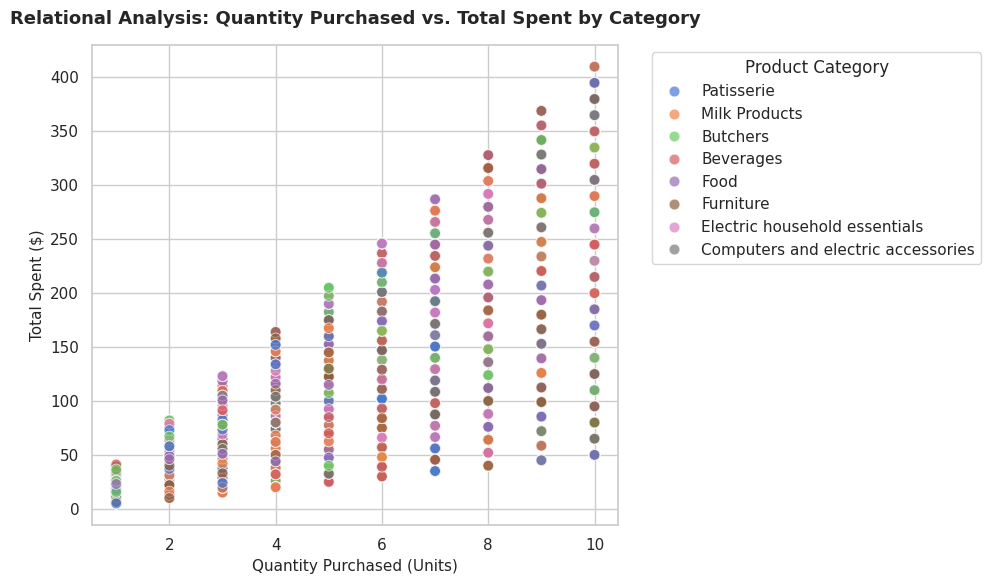

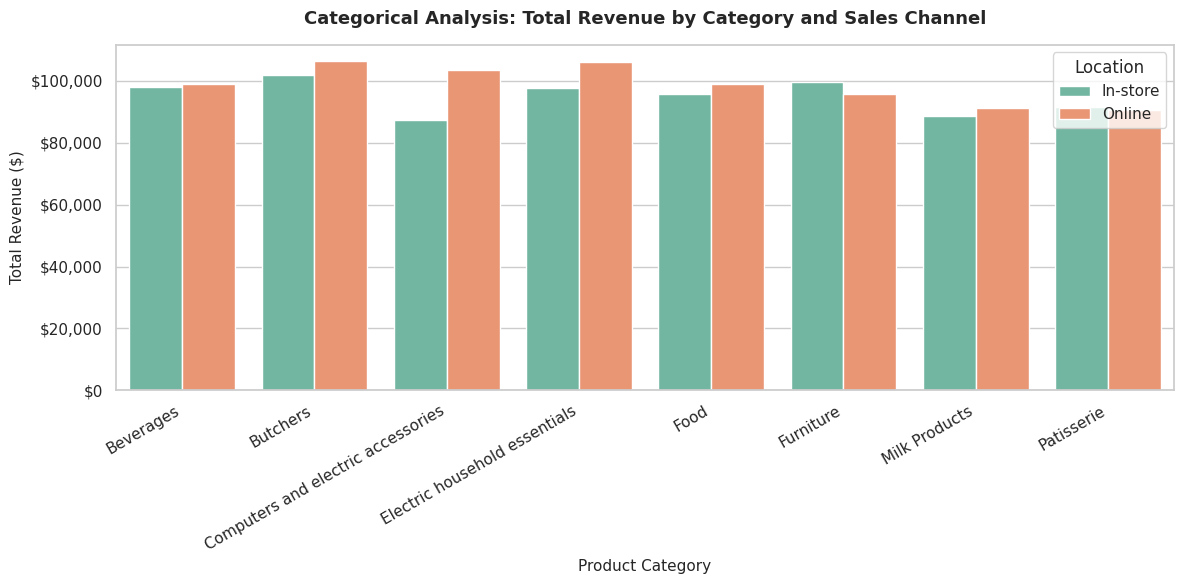

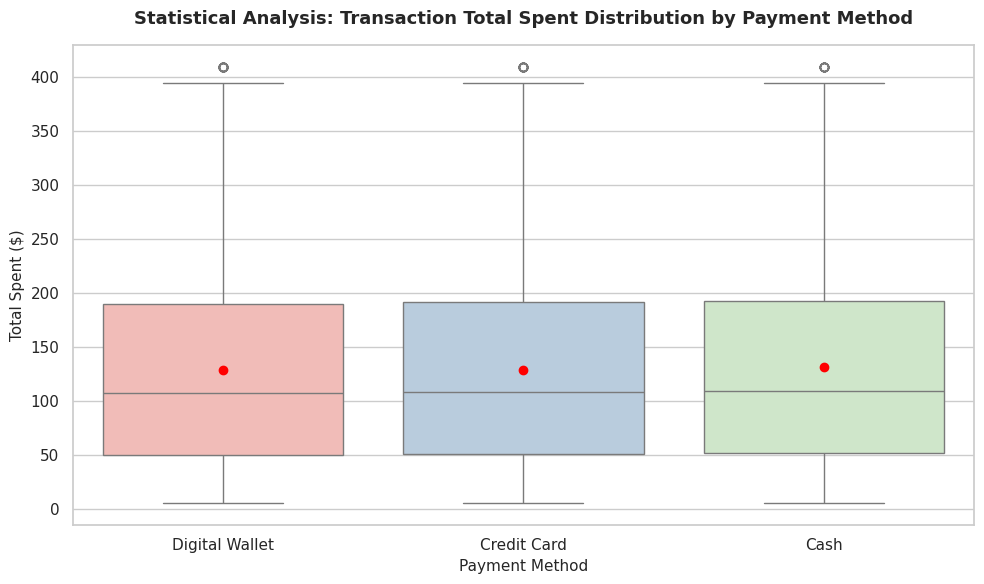

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set global aesthetic style for charts
sns.set_theme(style="whitegrid", palette="muted")


# ==========================================
# STEP 4: DEDICATED VISUALISATION FUNCTIONS
# ==========================================


def generate_relational_plot(
    df: pd.DataFrame, output_name: str = "relational_plot.png"
):
    """Plot Type 1: Relational Plot

    Scatter plot analyzing the relationship between Quantity Purchased and
    Total Spent across Product Categories.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x="Quantity",
        y="Total Spent",
        hue="Category",
        alpha=0.7,
        s=60,
        ax=ax,
    )

    ax.set_title(
        "Relational Analysis: Quantity Purchased vs. Total Spent by Category",
        fontsize=13,
        fontweight="bold",
        pad=15,
    )
    ax.set_xlabel("Quantity Purchased (Units)", fontsize=11)
    ax.set_ylabel("Total Spent ($)", fontsize=11)
    ax.legend(title="Product Category", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.savefig(output_name, dpi=300)
    plt.show()


def generate_categorical_plot(
    df: pd.DataFrame, output_name: str = "categorical_plot.png"
):
    """Plot Type 2: Categorical Plot

    Grouped bar chart comparing Total Revenue across Product Categories and
    Sales Channel Locations.
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    cat_sales = (
        df.groupby(["Category", "Location"])["Total Spent"]
        .sum()
        .reset_index()
    )

    sns.barplot(
        data=cat_sales,
        x="Category",
        y="Total Spent",
        hue="Location",
        palette="Set2",
        ax=ax,
    )

    ax.set_title(
        "Categorical Analysis: Total Revenue by Category and Sales Channel",
        fontsize=13,
        fontweight="bold",
        pad=15,
    )
    ax.set_xlabel("Product Category", fontsize=11)
    ax.set_ylabel("Total Revenue ($)", fontsize=11)
    plt.xticks(rotation=30, ha="right")
    ax.yaxis.set_major_formatter("${x:,.0f}")

    plt.tight_layout()
    plt.savefig(output_name, dpi=300)
    plt.show()


def generate_statistical_plot(
    df: pd.DataFrame, output_name: str = "statistical_plot.png"
):
    """Plot Type 3: Statistical Plot

    Boxplot illustrating the empirical distribution of spending across Payment
    Methods.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.boxplot(
        data=df,
        x="Payment Method",
        y="Total Spent",
        hue="Payment Method",
        palette="Pastel1",
        legend=False,
        showmeans=True,
        meanprops={
            "marker": "o",
            "markerfacecolor": "red",
            "markeredgecolor": "red",
        },
        ax=ax,
    )

    ax.set_title(
        "Statistical Analysis: Transaction Total Spent Distribution by Payment Method",
        fontsize=13,
        fontweight="bold",
        pad=15,
    )
    ax.set_xlabel("Payment Method", fontsize=11)
    ax.set_ylabel("Total Spent ($)", fontsize=11)

    plt.tight_layout()
    plt.savefig(output_name, dpi=300)
    plt.show()


# Execute chart generation functions
generate_relational_plot(cleaned_df)
generate_categorical_plot(cleaned_df)
generate_statistical_plot(cleaned_df)